# ⚽ FIFA World Cup Predictor
## End-to-End Data Science Project

**Pipeline completo:** Data Collection → Wrangling → Feature Engineering → EDA → ML/DL → GenAI

---
### Datasets necesarios (descargar de Kaggle → colocar en carpeta `db/`):
1. **`results.csv`** → [martj42/international-football-results-from-1872-to-2022](https://www.kaggle.com/datasets/martj42/international-football-results-from-1872-to-2022)
2. **`ranking.csv`** → [cashncarry/fifaworldranking](https://www.kaggle.com/datasets/cashncarry/fifaworldranking)
---

## 1. 📦 Setup e Importaciones

In [1]:
# ── PRIMERO: cargar el .env ──────────────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Silencia logs de TF
os.environ['CUDA_VISIBLE_DEVICES'] = ''            # No usar GPU (evita crash)
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'  # No reservar toda la RAM


from dotenv import load_dotenv
load_dotenv()

# ── LUEGO: el resto de imports ───────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from openai import OpenAI
import joblib

# ── GenAI: ahora sí encuentra la key ─────────
OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY
)

sns.set_theme(style='darkgrid', palette='husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

# Crear carpetas necesarias
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('db', exist_ok=True)

print('✅ Librerías importadas correctamente')
# print(f'   TensorFlow: {tf.__version__}')
print(f'   XGBoost:    {xgb.__version__}')
print(f'   OpenRouter key: {"✅ encontrada" if OPENROUTER_API_KEY else "❌ NO encontrada"}')

✅ Librerías importadas correctamente
   XGBoost:    3.2.0
   OpenRouter key: ✅ encontrada


## 2. 📂 Carga de Datos

In [2]:
# ─────────────────────────────────────────────
# Carga de los dos datasets principales
# ─────────────────────────────────────────────
results  = pd.read_csv('db/results.csv')
rankings = pd.read_csv('db/ranking.csv')

# Parsear fechas
results['date']         = pd.to_datetime(results['date'])
rankings['rank_date']   = pd.to_datetime(rankings['rank_date'])

print('📊 RESUMEN DE DATOS')
print('=' * 45)
print(f'  Partidos internacionales  : {len(results):>8,}')
print(f'  Registros de ranking FIFA : {len(rankings):>8,}')
print(f'  Período (partidos)        : {results["date"].min().year} – {results["date"].max().year}')
print(f'  Período (rankings)        : {rankings["rank_date"].min().year} – {rankings["rank_date"].max().year}')
print('\nColumnas de results.csv:')
print(results.columns.tolist())
print('\nColumnas de ranking.csv:')
print(rankings.columns.tolist())
results.head(3)

📊 RESUMEN DE DATOS
  Partidos internacionales  :   49,287
  Registros de ranking FIFA :   67,472
  Período (partidos)        : 1872 – 2026
  Período (rankings)        : 1992 – 2024

Columnas de results.csv:
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'city', 'country', 'neutral']

Columnas de ranking.csv:
['rank', 'country_full', 'country_abrv', 'total_points', 'previous_points', 'rank_change', 'confederation', 'rank_date']


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.000,0.000,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.000,2.000,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.000,1.000,Friendly,Glasgow,Scotland,False


## 3. 🔧 Limpieza y Preparación de Datos

In [3]:
# ── Inspección básica ──────────────────────────
print('VALORES NULOS en results.csv:')
print(results.isnull().sum()[results.isnull().sum() > 0])

print('\nTipos de dato:')
print(results.dtypes)

print(f'\nDuplicados: {results.duplicated().sum()}')

VALORES NULOS en results.csv:
home_score    72
away_score    72
dtype: int64

Tipos de dato:
date          datetime64[ns]
home_team             object
away_team             object
home_score           float64
away_score           float64
tournament            object
city                  object
country               object
neutral                 bool
dtype: object

Duplicados: 0


In [4]:
# ── Crear variable objetivo ────────────────────
def classify_result(row):
    if row['home_score'] > row['away_score']:  return 2  # local gana
    elif row['home_score'] == row['away_score']: return 1  # empate
    else:                                       return 0  # visitante gana

results['result']       = results.apply(classify_result, axis=1)
results['result_label'] = results['result'].map({2:'Local gana', 1:'Empate', 0:'Visitante gana'})

# ── Separar conjuntos útiles ───────────────────
# Todos los torneos competitivos (excl. amistosos)
tournaments_competitive = [
    'FIFA World Cup', 'FIFA World Cup qualification',
    'UEFA Euro', 'UEFA Euro qualification',
    'Copa América', 'AFC Asian Cup',
    'Africa Cup of Nations', 'CONCACAF Championship',
    'Confederations Cup'
]
df_comp = results[results['tournament'].isin(tournaments_competitive)].copy()

# Solo Mundiales (para análisis específico)
df_wc   = results[results['tournament'] == 'FIFA World Cup'].copy()

print(f'Partidos totales         : {len(results):,}')
print(f'Partidos competitivos    : {len(df_comp):,}')
print(f'Partidos de Copa Mundial : {len(df_wc):,}')
print(f'\nDistribución de resultados (Copa del Mundo):')
print(df_wc['result_label'].value_counts(normalize=True).map('{:.1%}'.format))

Partidos totales         : 49,287
Partidos competitivos    : 14,618
Partidos de Copa Mundial : 1,036

Distribución de resultados (Copa del Mundo):
result_label
Local gana        42.4%
Visitante gana    37.0%
Empate            20.7%
Name: proportion, dtype: object


## 4. 📊 Análisis Exploratorio de Datos (EDA)

Todos los partidos: {'Local gana': 24106, 'Visitante gana': 13984, 'Empate': 11197}
Partidos competitivos: {'Local gana': 7204, 'Visitante gana': 4330, 'Empate': 3084}
Copa del Mundo: {'Local gana': 439, 'Visitante gana': 383, 'Empate': 214}


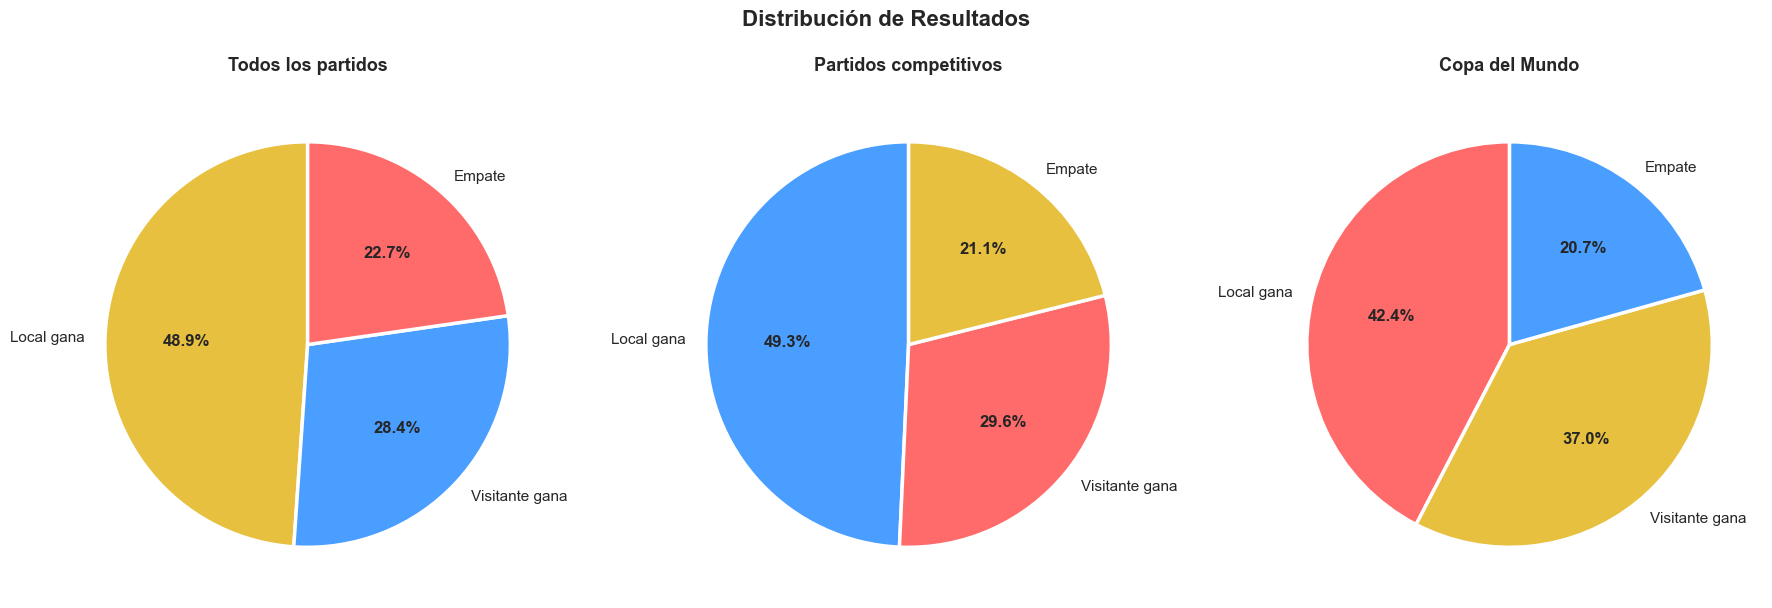

In [ ]:
import os
os.makedirs('plots', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Distribución de Resultados', fontsize=16, fontweight='bold', y=1.02)

datasets = [
    (results, 'Todos los partidos'),
    (df_comp, 'Partidos competitivos'),
    (df_wc,   'Copa del Mundo')
]

paletas = [
    ['#e8c040', '#4a9eff', '#ff6b6b'],
    ['#4a9eff', '#ff6b6b', '#e8c040'],
    ['#ff6b6b', '#e8c040', '#4a9eff'],
]

for ax, (df, title), colores in zip(axes, datasets, paletas):
    counts = df['result_label'].dropna().value_counts()  # ← dropna() aquí
    
    if len(counts) == 0:  # protección extra por si el df está vacío
        ax.set_title(f'{title}\n(sin datos)', fontsize=13)
        continue

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        autopct='%1.1f%%',
        colors=colores,
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2.5),
        textprops=dict(fontsize=11)
    )
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_fontsize(12)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=15)

    

plt.tight_layout()
plt.savefig('plots/eda_01_resultado_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

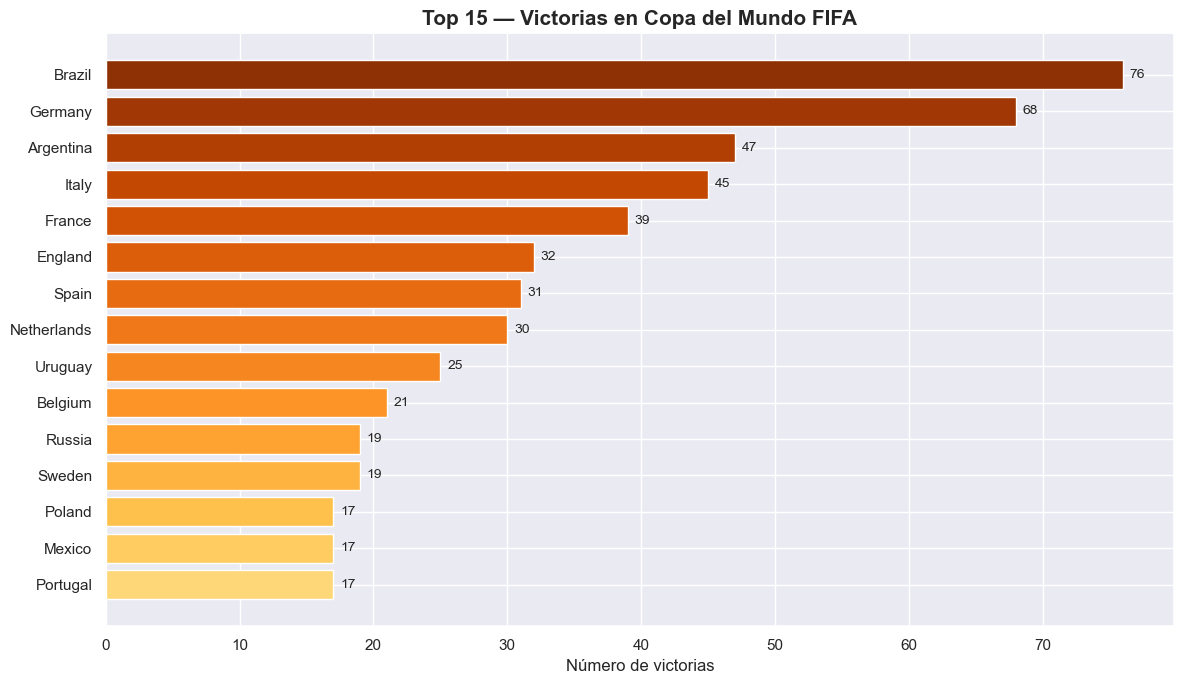

In [24]:
# ── Top 15 países con más victorias en Mundiales ─
wins_home = df_wc[df_wc['home_score'] > df_wc['away_score']].groupby('home_team').size()
wins_away = df_wc[df_wc['away_score'] > df_wc['home_score']].groupby('away_team').size()
total_wins = wins_home.add(wins_away, fill_value=0).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(total_wins.index[::-1], total_wins.values[::-1],
               color=plt.cm.YlOrBr(np.linspace(0.3, 0.9, len(total_wins))))
ax.set_xlabel('Número de victorias', fontsize=12)
ax.set_title('Top 15 — Victorias en Copa del Mundo FIFA', fontsize=15, fontweight='bold')
for bar, val in zip(bars, total_wins.values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{int(val)}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('plots/eda_02_top_equipos.png', dpi=150, bbox_inches='tight')
plt.show()

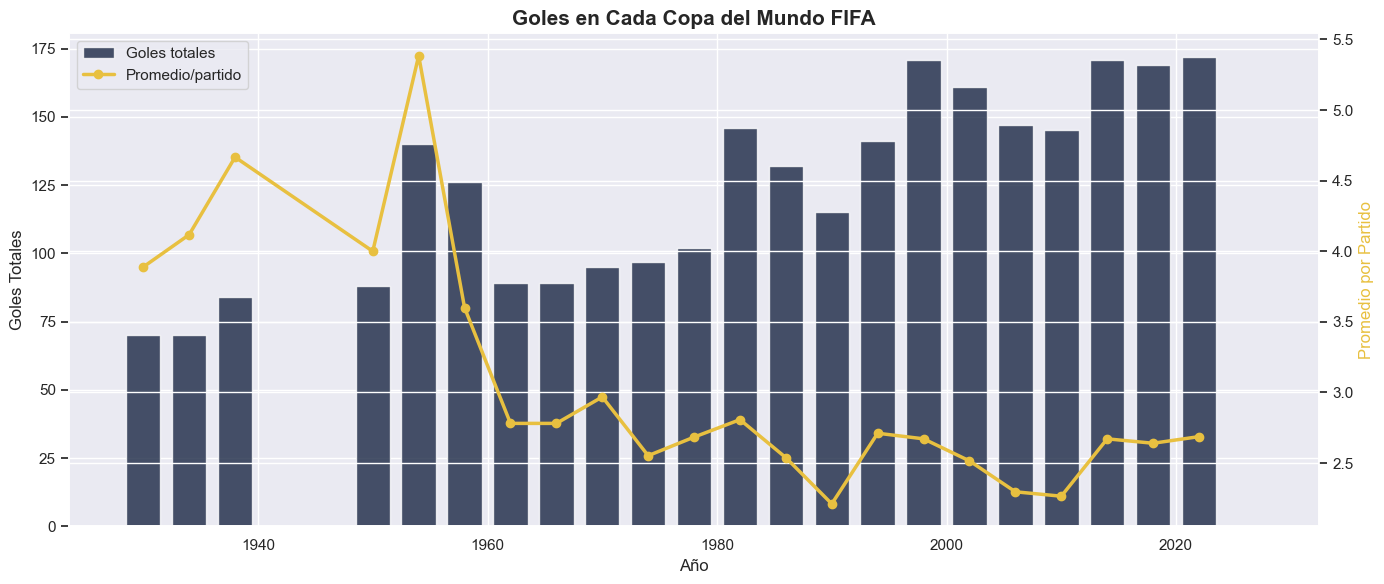

In [7]:
# ── Goles por edición del Mundial ─────────────────
df_wc_copy         = df_wc.copy()
df_wc_copy['year'] = df_wc_copy['date'].dt.year
df_wc_copy['total_goals'] = df_wc_copy['home_score'] + df_wc_copy['away_score']

by_year = df_wc_copy.groupby('year').agg(
    total_goals=('total_goals', 'sum'),
    matches=('total_goals', 'count')
).reset_index()
by_year['avg_goals'] = by_year['total_goals'] / by_year['matches']

fig, ax1 = plt.subplots(figsize=(14, 6))
ax2 = ax1.twinx()

ax1.bar(by_year['year'], by_year['total_goals'],
        color='#1a2744', alpha=0.8, label='Goles totales', width=3)
ax2.plot(by_year['year'], by_year['avg_goals'],
         color='#e8c040', linewidth=2.5, marker='o', label='Promedio/partido')

ax1.set_xlabel('Año', fontsize=12)
ax1.set_ylabel('Goles Totales', fontsize=12)
ax2.set_ylabel('Promedio por Partido', fontsize=12, color='#e8c040')
ax1.set_title('Goles en Cada Copa del Mundo FIFA', fontsize=15, fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('plots/eda_03_goles_por_anio.png', dpi=150, bbox_inches='tight')
plt.show()

TASA DE VICTORIA COMO LOCAL vs VISITANTE (Copa del Mundo):
  Local gana  : 42.4%
  Visitante   : 37.0%
  Empate      : 20.7%


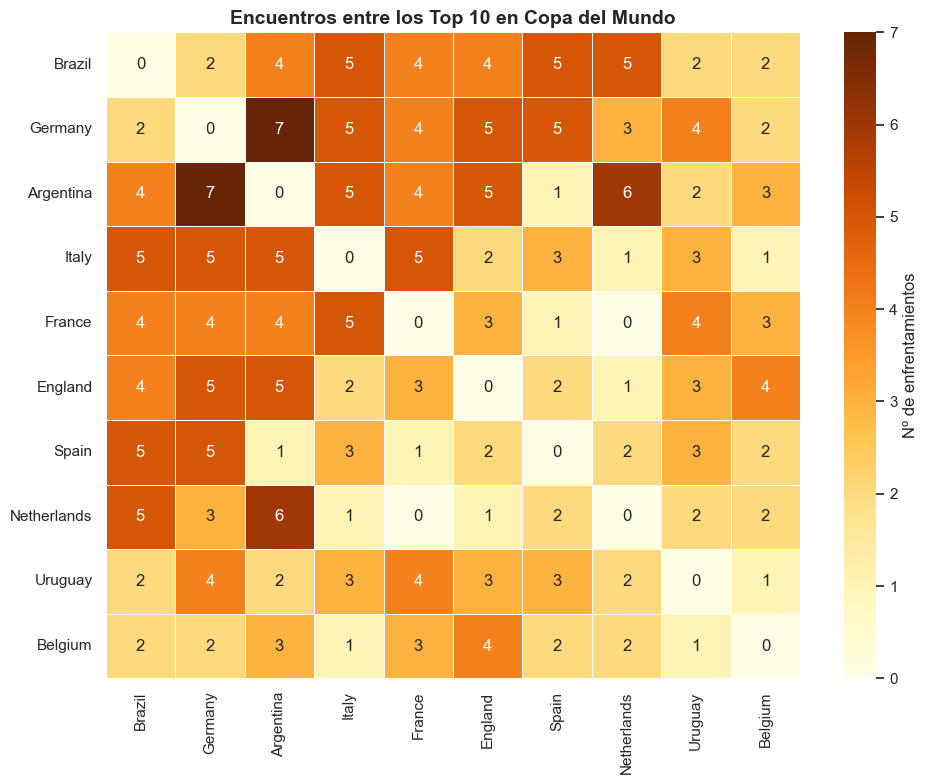

In [8]:
# ── Ventaja de jugar como local ───────────────────
print('TASA DE VICTORIA COMO LOCAL vs VISITANTE (Copa del Mundo):')
home_win_rate = (df_wc['result'] == 2).mean()
away_win_rate = (df_wc['result'] == 0).mean()
draw_rate     = (df_wc['result'] == 1).mean()

print(f'  Local gana  : {home_win_rate:.1%}')
print(f'  Visitante   : {away_win_rate:.1%}')
print(f'  Empate      : {draw_rate:.1%}')

# Heatmap de enfrentamientos entre top equipos
top_teams = total_wins.head(10).index.tolist()
heat_data = pd.DataFrame(0, index=top_teams, columns=top_teams)

for team_h in top_teams:
    for team_a in top_teams:
        if team_h != team_a:
            h2h = df_wc[
                ((df_wc['home_team'] == team_h) & (df_wc['away_team'] == team_a)) |
                ((df_wc['home_team'] == team_a) & (df_wc['away_team'] == team_h))
            ]
            heat_data.loc[team_h, team_a] = len(h2h)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heat_data, annot=True, fmt='d', cmap='YlOrBr',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Nº de enfrentamientos'})
ax.set_title('Encuentros entre los Top 10 en Copa del Mundo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_04_heatmap_h2h.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. ⚙️ Feature Engineering

Construimos **13 features contextuales** para cada partido:
- Rankings FIFA (proxy de calidad del equipo)
- Forma reciente (últimos 10 partidos)
- Estadísticas Head-to-Head históricas
- Promedio de goles
- Campo neutral

In [9]:
# ──────────────────────────────────────────────
# FUNCIONES DE FEATURE ENGINEERING
# ──────────────────────────────────────────────

def get_form(team, date, df, n=10):
    """% de victorias en los últimos n partidos del equipo"""
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date)
    ].tail(n)
    if len(past) == 0:
        return 0.4  # Valor neutral por defecto
    wins = sum(
        1 for _, r in past.iterrows()
        if (r['home_team'] == team and r['home_score'] > r['away_score']) or
           (r['away_team'] == team and r['away_score'] > r['home_score'])
    )
    return wins / len(past)


def get_avg_goals(team, date, df, n=10):
    """Promedio de goles marcados en últimos n partidos"""
    past = df[
        ((df['home_team'] == team) | (df['away_team'] == team)) &
        (df['date'] < date)
    ].tail(n)
    if len(past) == 0:
        return 1.2
    total = sum(
        r['home_score'] if r['home_team'] == team else r['away_score']
        for _, r in past.iterrows()
    )
    return total / len(past)


def get_h2h(home, away, date, df):
    """Estadísticas head-to-head previas al partido"""
    h2h = df[
        (((df['home_team'] == home) & (df['away_team'] == away)) |
         ((df['home_team'] == away) & (df['away_team'] == home))) &
        (df['date'] < date)
    ]
    total = len(h2h)
    if total == 0:
        return {'total': 0, 'hw_rate': 0.33, 'draw_rate': 0.33, 'aw_rate': 0.33}

    hw = len(h2h[
        ((h2h['home_team'] == home) & (h2h['home_score'] > h2h['away_score'])) |
        ((h2h['away_team'] == home) & (h2h['away_score'] > h2h['home_score']))
    ])
    aw = len(h2h[
        ((h2h['home_team'] == away) & (h2h['home_score'] > h2h['away_score'])) |
        ((h2h['away_team'] == away) & (h2h['away_score'] > h2h['home_score']))
    ])
    draws = total - hw - aw
    return {
        'total':     total,
        'hw_rate':   hw    / total,
        'draw_rate': draws / total,
        'aw_rate':   aw    / total
    }


def get_ranking(team, date, rankings_df):
    """Ranking FIFA más reciente anterior a la fecha del partido"""
    tr = rankings_df[
        (rankings_df['country_full'] == team) &
        (rankings_df['rank_date'] <= date)
    ]
    if len(tr) == 0:
        return 100  # Valor por defecto
    return int(tr.sort_values('rank_date').iloc[-1]['rank'])


print('✅ Funciones de feature engineering definidas')

✅ Funciones de feature engineering definidas


In [10]:
# ──────────────────────────────────────────────
# CONSTRUCCIÓN DEL DATASET DE FEATURES
# Usamos todos los partidos competitivos para
# tener más datos de entrenamiento
# ──────────────────────────────────────────────
df_train_raw = df_comp.copy().reset_index(drop=True)
print(f'Construyendo features para {len(df_train_raw):,} partidos...')
print('⏳ Esto puede tardar entre 3 y 8 minutos...')

FEATURE_NAMES = [
    'home_ranking', 'away_ranking', 'ranking_diff',
    'home_form', 'away_form', 'form_diff',
    'home_goals_avg', 'away_goals_avg',
    'h2h_home_win_rate', 'h2h_draw_rate', 'h2h_away_win_rate',
    'h2h_total', 'is_neutral'
]

rows = []
for idx, row in df_train_raw.iterrows():
    if idx % 500 == 0:
        print(f'  {idx:>5} / {len(df_train_raw)} partidos procesados...')

    home, away, date = row['home_team'], row['away_team'], row['date']

    h_rank = get_ranking(home, date, rankings)
    a_rank = get_ranking(away, date, rankings)
    h_form = get_form(home, date, results)
    a_form = get_form(away, date, results)
    h_goal = get_avg_goals(home, date, results)
    a_goal = get_avg_goals(away, date, results)
    h2h    = get_h2h(home, away, date, results)

    rows.append([
        h_rank, a_rank, h_rank - a_rank,
        h_form, a_form, h_form - a_form,
        h_goal, a_goal,
        h2h['hw_rate'], h2h['draw_rate'], h2h['aw_rate'],
        h2h['total'],
        int(row['neutral']),
        row['result']
    ])

df_features = pd.DataFrame(rows, columns=FEATURE_NAMES + ['result'])
df_features.to_csv('db/features_engineered.csv', index=False)
print(f'\n✅ Features construidas: {df_features.shape}')
df_features.describe()

Construyendo features para 14,618 partidos...
⏳ Esto puede tardar entre 3 y 8 minutos...
      0 / 14618 partidos procesados...
    500 / 14618 partidos procesados...
   1000 / 14618 partidos procesados...
   1500 / 14618 partidos procesados...
   2000 / 14618 partidos procesados...
   2500 / 14618 partidos procesados...
   3000 / 14618 partidos procesados...
   3500 / 14618 partidos procesados...
   4000 / 14618 partidos procesados...
   4500 / 14618 partidos procesados...
   5000 / 14618 partidos procesados...
   5500 / 14618 partidos procesados...
   6000 / 14618 partidos procesados...
   6500 / 14618 partidos procesados...
   7000 / 14618 partidos procesados...
   7500 / 14618 partidos procesados...
   8000 / 14618 partidos procesados...
   8500 / 14618 partidos procesados...
   9000 / 14618 partidos procesados...
   9500 / 14618 partidos procesados...
  10000 / 14618 partidos procesados...
  10500 / 14618 partidos procesados...
  11000 / 14618 partidos procesados...
  11500 / 1461

,home_ranking,away_ranking,ranking_diff,home_form,away_form,form_diff,home_goals_avg,away_goals_avg,h2h_home_win_rate,h2h_draw_rate,h2h_away_win_rate,h2h_total,is_neutral,result
count,14618.000,14618.000,14618.000,14618.000,14618.000,14618.000,14570.000,14570.000,14618.000,14618.000,14618.000,14618.000,14618.000,14618.000
mean,79.131,80.027,-0.897,0.399,0.394,0.005,1.428,1.414,0.391,0.217,0.391,10.911,0.214,1.197
std,45.032,45.022,51.778,0.207,0.203,0.278,0.672,0.660,0.310,0.206,0.314,17.149,0.410,0.866
min,1.000,1.000,-209.000,0.000,0.000,-0.900,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,40.000,42.000,-23.000,0.300,0.200,-0.200,1.000,1.000,0.143,0.000,0.143,2.000,0.000,0.000
50%,100.000,100.000,0.000,0.400,0.400,0.000,1.400,1.300,0.330,0.206,0.330,5.000,0.000,1.000
75%,100.000,100.000,20.000,0.500,0.500,0.200,1.800,1.800,0.588,0.330,0.588,13.000,0.000,2.000
max,211.000,211.000,210.000,1.000,1.000,1.000,8.600,7.600,1.000,1.000,1.000,182.000,1.000,2.000


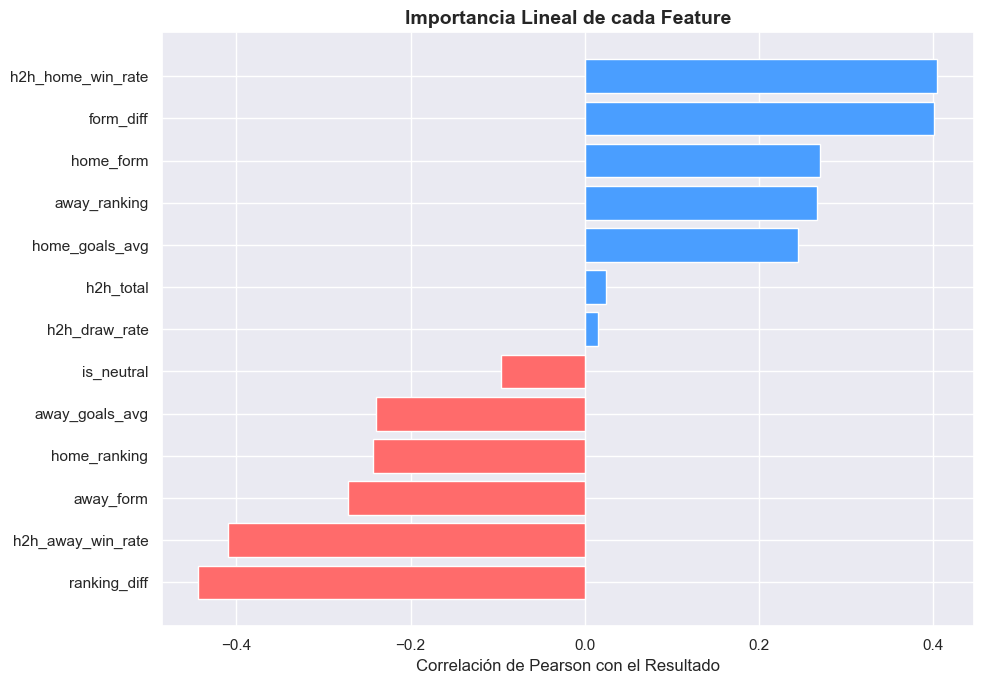

In [11]:
# ── Correlación de features con el resultado ───
fig, ax = plt.subplots(figsize=(10, 7))
corr = df_features.corr()[['result']].drop('result').sort_values('result')
colors = ['#ff6b6b' if v < 0 else '#4a9eff' for v in corr['result']]
ax.barh(corr.index, corr['result'], color=colors)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_xlabel('Correlación de Pearson con el Resultado', fontsize=12)
ax.set_title('Importancia Lineal de cada Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/eda_05_correlacion_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 🤖 Machine Learning & Deep Learning

Entrenamos y comparamos **3 modelos**:
1. **XGBoost** — Gradient Boosting (modelo principal)
2. **Random Forest** — Ensemble de árboles
3. **Red Neuronal MLP** — Deep Learning con Keras

In [12]:
# ── Preprocesamiento ────────────────────────────
# Cargar features precalculadas (si ya se calcularon antes)
# df_features = pd.read_csv('db/features_engineered.csv')

X = df_features[FEATURE_NAMES].values
y = df_features['result'].values

# Train / Test split (80/20, estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado (necesario para la red neuronal)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} muestras')
print(f'Test : {X_test.shape[0]:,} muestras')
print(f'Features: {X_train.shape[1]}')
print(f'\nDistribución de clases en train:')
for cls, name in {0:'Visitante gana', 1:'Empate', 2:'Local gana'}.items():
    print(f'  {name}: {(y_train == cls).sum():,} ({(y_train == cls).mean():.1%})')

Train: 11,694 muestras
Test : 2,924 muestras
Features: 13

Distribución de clases en train:
  Visitante gana: 3,464 (29.6%)
  Empate: 2,467 (21.1%)
  Local gana: 5,763 (49.3%)


In [13]:
# ──────────────────────────────────────────────
# MODELO 1: XGBoost
# ──────────────────────────────────────────────
print('Entrenando XGBoost...')

# Modelo principal (con early stopping para el entrenamiento final)
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    early_stopping_rounds=20,
    verbosity=0
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict(X_test)
xgb_acc   = accuracy_score(y_test, xgb_preds)

# Modelo separado para cross-validation (sin early_stopping_rounds)
# porque cross_val_score no soporta eval_set internamente
xgb_cv = xgb.XGBClassifier(
    n_estimators=xgb_model.best_iteration or 100,  # usa el nº óptimo encontrado
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    verbosity=0
)
cv_scores = cross_val_score(xgb_cv, X_train, y_train, cv=5, scoring='accuracy')

print(f'\n✅ XGBoost entrenado')
print(f'   Best iteration   : {xgb_model.best_iteration}')
print(f'   Test Accuracy    : {xgb_acc:.3f}')
print(f'   CV Accuracy (5K) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'\n{classification_report(y_test, xgb_preds, target_names=["Visitante gana","Empate","Local gana"])}')

Entrenando XGBoost...

✅ XGBoost entrenado
   Best iteration   : 90
   Test Accuracy    : 0.615
   CV Accuracy (5K) : 0.618 ± 0.005

                precision    recall  f1-score   support

Visitante gana       0.55      0.67      0.61       866
        Empate       0.43      0.02      0.03       617
    Local gana       0.65      0.84      0.73      1441

      accuracy                           0.62      2924
     macro avg       0.55      0.51      0.46      2924
  weighted avg       0.58      0.62      0.55      2924



In [14]:
# ──────────────────────────────────────────────
# MODELO 2: Random Forest
# ──────────────────────────────────────────────
print('Entrenando Random Forest...')

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_acc   = accuracy_score(y_test, rf_preds)

cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print(f'\n✅ Random Forest entrenado')
print(f'   Test Accuracy    : {rf_acc:.3f}')
print(f'   CV Accuracy (5K) : {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(f'\nTop 5 features más importantes:')
print(importances.head())

Entrenando Random Forest...

✅ Random Forest entrenado
   Test Accuracy    : 0.614
   CV Accuracy (5K) : 0.615 ± 0.004

Top 5 features más importantes:
ranking_diff        0.191
h2h_home_win_rate   0.143
h2h_away_win_rate   0.119
form_diff           0.089
home_goals_avg      0.072
dtype: float64


Entrenando Red Neuronal...

✅ Red Neuronal entrenada
   Test Accuracy : 0.493


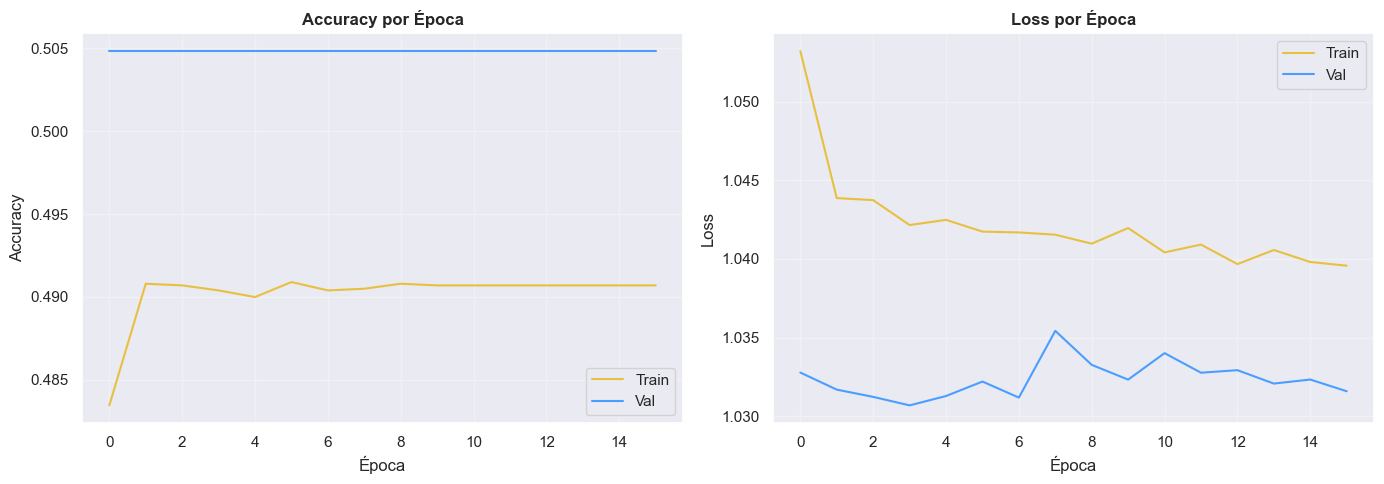

In [15]:
# ──────────────────────────────────────────────
# MODELO 3: Red Neuronal (Deep Learning)
# ──────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print('Entrenando Red Neuronal...')

dl_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(3, activation='softmax')  # 3 clases: 0, 1, 2
])

dl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=7, factor=0.5, min_lr=1e-5)
]

history = dl_model.fit(
    X_train_sc, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=0
)

_, dl_acc = dl_model.evaluate(X_test_sc, y_test, verbose=0)
print(f'\n✅ Red Neuronal entrenada')
print(f'   Test Accuracy : {dl_acc:.3f}')

# Curva de aprendizaje
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'],     label='Train', color='#e8c040')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#4a9eff')
ax1.set_title('Accuracy por Época', fontweight='bold')
ax1.set_xlabel('Época'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(history.history['loss'],     label='Train', color='#e8c040')
ax2.plot(history.history['val_loss'], label='Val',   color='#4a9eff')
ax2.set_title('Loss por Época', fontweight='bold')
ax2.set_xlabel('Época'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('plots/dl_curva_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()

RESUMEN DE MODELOS:
       Modelo  Accuracy  CV Mean  CV Std
      XGBoost     0.615    0.618   0.005
Random Forest     0.614    0.615   0.004
 Red Neuronal     0.493      NaN     NaN


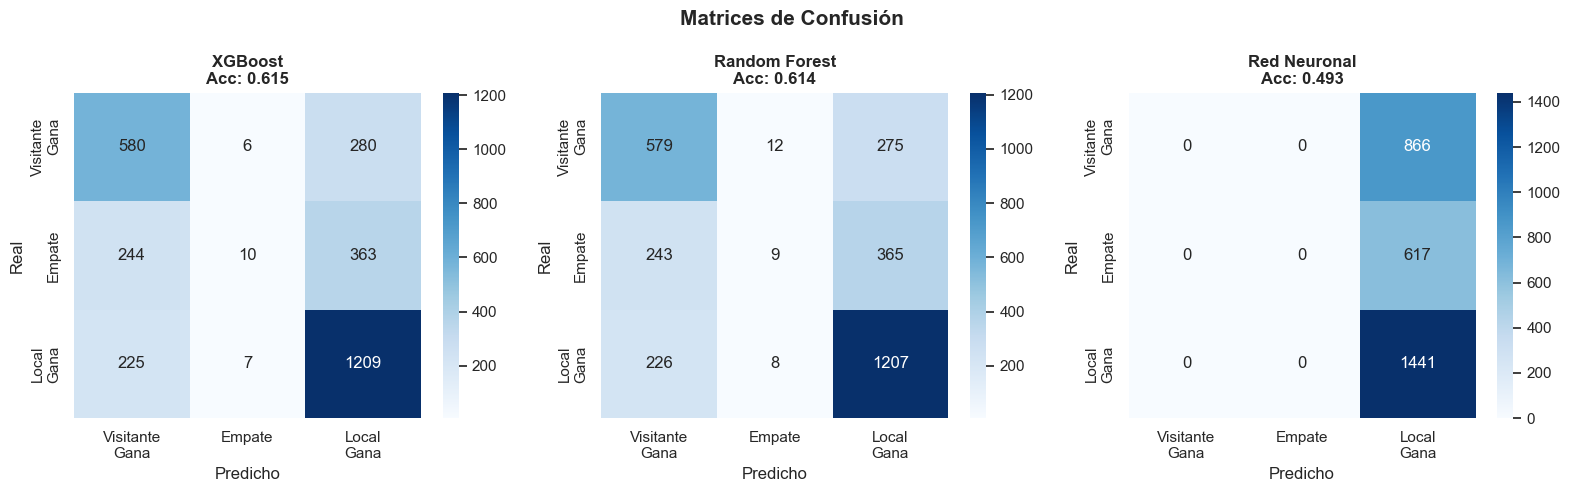

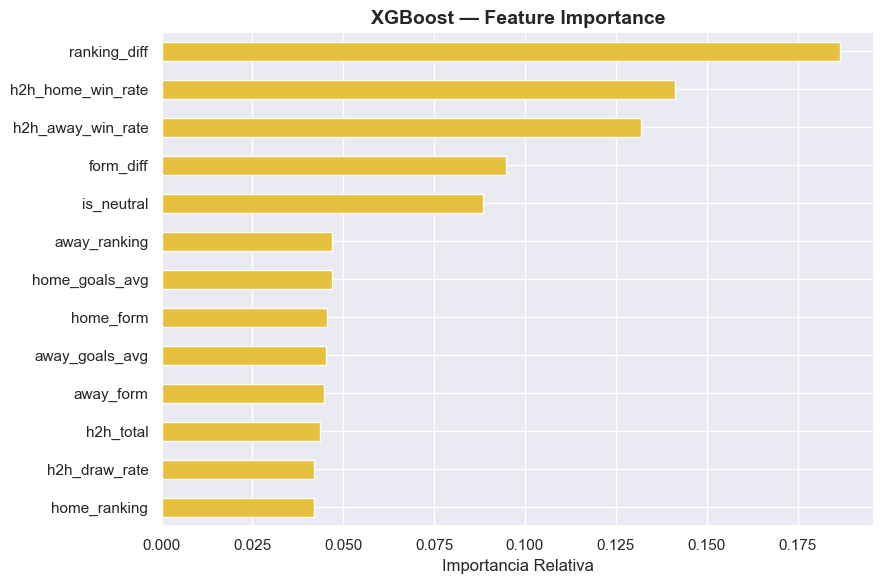

In [16]:
# ──────────────────────────────────────────────
# COMPARACIÓN DE MODELOS
# ──────────────────────────────────────────────
dl_preds = np.argmax(dl_model.predict(X_test_sc, verbose=0), axis=1)

results_summary = {
    'Modelo':    ['XGBoost', 'Random Forest', 'Red Neuronal'],
    'Accuracy':  [xgb_acc, rf_acc, dl_acc],
    'CV Mean':   [cv_scores.mean(), cv_rf.mean(), None],
    'CV Std':    [cv_scores.std(),  cv_rf.std(),  None],
}
df_results = pd.DataFrame(results_summary)
print('RESUMEN DE MODELOS:')
print(df_results.to_string(index=False))

# Matriz de confusión del mejor modelo (XGBoost)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Matrices de Confusión', fontsize=15, fontweight='bold')

class_names = ['Visitante\nGana', 'Empate', 'Local\nGana']
for ax, (preds, name) in zip(axes, [
    (xgb_preds, 'XGBoost'),
    (rf_preds, 'Random Forest'),
    (dl_preds, 'Red Neuronal')
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'{name}\nAcc: {accuracy_score(y_test, preds):.3f}', fontweight='bold')
    ax.set_ylabel('Real'); ax.set_xlabel('Predicho')

plt.tight_layout()
plt.savefig('plots/ml_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance (XGBoost)
xgb_importances = pd.Series(
    xgb_model.feature_importances_, index=FEATURE_NAMES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
xgb_importances.plot.barh(ax=ax, color='#e8c040')
ax.set_title('XGBoost — Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia Relativa')
plt.tight_layout()
plt.savefig('plots/ml_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. 🤖 Integración GenAI 



In [ ]:
# ──────────────────────────────────────────────
# CONFIGURACIÓN GROQ
# Opción A: desde .env (recomendado)
# Opción B: directamente aquí (no subir a GitHub)
# ──────────────────────────────────────────────
# GROQ_API_KEY = os.getenv('GROQ_API_KEY', 'TU_API_KEY_AQUI')
# client = Groq(api_key=GROQ_API_KEY)
# print('✅ Cliente Groq configurado')


# # ANTES (Groq)
# from groq import Groq
# client = Groq(api_key=GROQ_API_KEY)
# response = client.chat.completions.create(
#     model="llama-3.3-70b-versatile"
# )

#-------------------------------------------------------------------------------------------------------------

# DESPUÉS (OpenRouter) — misma API, diferente URL y modelo
# from openai import OpenAI
# client = OpenAI(
#     base_url="https://openrouter.ai/api/v1",
#     api_key=OPENROUTER_API_KEY
# )

# # Test rápido para verificar que la conexión funciona
# response = client.chat.completions.create(
#     model="meta-llama/llama-3.3-70b-instruct:free",
#     messages=[
#         {"role": "user", "content": "Di 'Conexión exitosa con OpenRouter' y nada más."}
#     ]
# )

# print(response.choices[0].message.content)
# print("✅ Cliente OpenRouter configurado correctamente")


# -----------------------------------------------------------------------------------------------------------

# Reemplaza con el nombre EXACTO que apareció en la lista
# MODEL = "google/gemma-4-26b-a4b-it:free"  

# def call_llm(messages, model=MODEL, retries=3):
#     for attempt in range(retries):
#         try:
#             response = client.chat.completions.create(
#                 model=model,
#                 messages=messages
#             )
#             return response.choices[0].message.content
#         except Exception as e:
#             if "429" in str(e) and attempt < retries - 1:
#                 print(f"Rate limit, esperando 10s... (intento {attempt+1}/{retries})")
#                 time.sleep(10)
#             else:
#                 raise e

# print(call_llm([{"role": "user", "content": "Di 'Conexión exitosa' y nada más."}]))



# -----------------------------------------------------------------------------------------------------------
# import requests

# # Ver todos los modelos gratuitos disponibles AHORA en OpenRouter
# response = requests.get("https://openrouter.ai/api/v1/models")
# models = response.json()['data']

# # Filtrar solo los gratuitos
# free_models = [m for m in models if ':free' in m['id']]

# print(f"Modelos gratuitos disponibles ({len(free_models)}):\n")
# for m in free_models:
#     print(f"  {m['id']}")

# -----------------------------------------------------------------------------------------------------------



import time

MODELOS_FALLBACK = [
    "meta-llama/llama-3.3-70b-instruct:free",
    "nvidia/nemotron-3-super-120b-a12b:free",
    "meta-llama/llama-3.2-3b-instruct:free",
    "google/gemma-3-27b-it:free",       # sin system role
    "google/gemma-3-12b-it:free",       # sin system role
    "google/gemma-3-4b-it:free",        # sin system role
]

# Modelos que NO soportan rol 'system'
MODELOS_SIN_SYSTEM = ["gemma", "google/gemma"]

def adaptar_mensajes(messages, modelo):
    """Convierte el rol 'system' a 'user' para modelos que no lo soportan"""
    if not any(m in modelo for m in ["gemma"]):
        return messages  # modelo normal, no tocar nada
    
    # Para Gemma: fusionar system + primer user en un solo mensaje user
    adaptados = []
    system_content = ""
    for msg in messages:
        if msg["role"] == "system":
            system_content = msg["content"] + "\n\n"
        elif msg["role"] == "user" and system_content:
            adaptados.append({"role": "user", "content": system_content + msg["content"]})
            system_content = ""
        else:
            adaptados.append(msg)
    return adaptados


def call_llm_con_fallback(messages, max_tokens=500, temperature=0.7):
    for modelo in MODELOS_FALLBACK:
        try:
            print(f"   Intentando con {modelo}...")
            msgs_adaptados = adaptar_mensajes(messages, modelo)
            response = client.chat.completions.create(
                model=modelo,
                messages=msgs_adaptados,
                max_tokens=max_tokens,
                temperature=temperature
            )
            print(f"   ✅ Éxito con {modelo}")
            return response.choices[0].message.content
        except Exception as e:
            # Capturar tanto 429 (rate limit) como 400 (bad request / no system role)
            if "429" in str(e) or "400" in str(e) or "rate" in str(e).lower():
                print(f"   ⚠️ Error ({str(e)[:60]}...), probando siguiente...")
                time.sleep(2)
                continue
            else:
                raise e
    return "⚠️ Análisis no disponible temporalmente."



Modelos gratuitos disponibles (24):

  google/gemma-4-26b-a4b-it:free
  google/gemma-4-31b-it:free
  nvidia/nemotron-3-super-120b-a12b:free
  minimax/minimax-m2.5:free
  arcee-ai/trinity-large-preview:free
  liquid/lfm-2.5-1.2b-thinking:free
  liquid/lfm-2.5-1.2b-instruct:free
  nvidia/nemotron-3-nano-30b-a3b:free
  nvidia/nemotron-nano-12b-v2-vl:free
  qwen/qwen3-next-80b-a3b-instruct:free
  nvidia/nemotron-nano-9b-v2:free
  openai/gpt-oss-120b:free
  openai/gpt-oss-20b:free
  z-ai/glm-4.5-air:free
  qwen/qwen3-coder:free
  cognitivecomputations/dolphin-mistral-24b-venice-edition:free
  google/gemma-3n-e2b-it:free
  google/gemma-3n-e4b-it:free
  google/gemma-3-4b-it:free
  google/gemma-3-12b-it:free
  google/gemma-3-27b-it:free
  meta-llama/llama-3.3-70b-instruct:free
  meta-llama/llama-3.2-3b-instruct:free
  nousresearch/hermes-3-llama-3.1-405b:free


In [ ]:



# ── Esta función queda igual que antes ───────────
def preparar_contexto_partido(home, away, resultados_df, rankings_df):
    """Prepara el contexto estadístico real para pasarle al LLM"""
    today = pd.Timestamp.now()
    h2h    = get_h2h(home, away, today, resultados_df)
    h_rank = get_ranking(home, today, rankings_df)
    a_rank = get_ranking(away, today, rankings_df)
    h_form = get_form(home, today, resultados_df)
    a_form = get_form(away, today, resultados_df)

    wc_copy = df_wc.copy()
    wc_copy['year'] = wc_copy['date'].dt.year
    wc_home = wc_copy[(wc_copy['home_team'] == home) | (wc_copy['away_team'] == home)]
    wc_away = wc_copy[(wc_copy['home_team'] == away) | (wc_copy['away_team'] == away)]

    return {
        'home': home,
        'away': away,
        'home_rank': h_rank,
        'away_rank': a_rank,
        'home_form_pct': f"{h_form:.0%}",
        'away_form_pct': f"{a_form:.0%}",
        'h2h_total': h2h['total'],
        'h2h_home_wins': int(h2h['hw_rate'] * h2h['total']) if h2h['total'] > 0 else 0,
        'h2h_draws':     int(h2h['draw_rate'] * h2h['total']) if h2h['total'] > 0 else 0,
        'h2h_away_wins': int(h2h['aw_rate'] * h2h['total']) if h2h['total'] > 0 else 0,
        'home_wc_appearances': wc_home['year'].nunique(),
        'away_wc_appearances': wc_away['year'].nunique(),
    }


# ── Ahora usa call_llm_con_fallback en lugar de client directo ──
def analizar_partido_con_ia(home, away, prediction, proba, resultados_df, rankings_df, idioma='es'):
    """Genera análisis deportivo real usando LLM + datos del dataset"""
    ctx = preparar_contexto_partido(home, away, resultados_df, rankings_df)

    labels = {2: f'Victoria de {home}', 1: 'Empate', 0: f'Victoria de {away}'}
    pred_label = labels[prediction]
    conf = max(proba)

    if idioma == 'es':
        prompt = f"""Eres un analista deportivo experto en fútbol internacional. Genera un análisis profesional basado en los siguientes datos REALES:

PARTIDO: {home} (local) vs {away} (visitante)

DATOS ESTADÍSTICOS:
- Ranking FIFA: {home} #{ctx['home_rank']} | {away} #{ctx['away_rank']}
- Forma reciente (% victorias últimos 10 partidos): {home} {ctx['home_form_pct']} | {away} {ctx['away_form_pct']}
- Historial H2H ({ctx['h2h_total']} partidos): {home} {ctx['h2h_home_wins']} victorias, {ctx['h2h_draws']} empates, {away} {ctx['h2h_away_wins']} victorias
- Participaciones en Mundiales: {home} ({ctx['home_wc_appearances']} ediciones) | {away} ({ctx['away_wc_appearances']} ediciones)
- Predicción del modelo ML: {pred_label} (confianza: {conf:.0%})

Escribe 3 párrafos en español:
1. Contexto y forma actual de ambos equipos
2. Historia del enfrentamiento (H2H)
3. Pronóstico fundamentado y conclusión"""
    else:
        prompt = f"""You are an expert sports analyst. Generate a professional analysis based on this REAL data:
Match: {home} (home) vs {away} (away)
FIFA Rank: {home} #{ctx['home_rank']} | {away} #{ctx['away_rank']}
Recent form: {home} {ctx['home_form_pct']} wins | {away} {ctx['away_form_pct']} wins
H2H ({ctx['h2h_total']} games): {home} {ctx['h2h_home_wins']}W {ctx['h2h_draws']}D {away} {ctx['h2h_away_wins']}W
ML Prediction: {pred_label} (confidence: {conf:.0%})
Write 3 paragraphs: current form, H2H history, and prediction."""

    return call_llm_con_fallback(
        messages=[{'role': 'user', 'content': prompt}],
        max_tokens=500,
        temperature=0.7
    )


print('✅ Funciones GenAI definidas')

✅ Funciones GenAI definidas


In [ ]:
# ── Demo: predicción + análisis IA ─────────────
HOME_TEAM = 'Uruguay'
AWAY_TEAM = 'Argentina'

# 1. Construir features para este partido
today = pd.Timestamp.now()
feat_row = np.array([[
    get_ranking(HOME_TEAM, today, rankings),
    get_ranking(AWAY_TEAM, today, rankings),
    get_ranking(HOME_TEAM, today, rankings) - get_ranking(AWAY_TEAM, today, rankings),
    get_form(HOME_TEAM, today, results),
    get_form(AWAY_TEAM, today, results),
    get_form(HOME_TEAM, today, results) - get_form(AWAY_TEAM, today, results),
    get_avg_goals(HOME_TEAM, today, results),
    get_avg_goals(AWAY_TEAM, today, results),
    get_h2h(HOME_TEAM, AWAY_TEAM, today, results)['hw_rate'],
    get_h2h(HOME_TEAM, AWAY_TEAM, today, results)['draw_rate'],
    get_h2h(HOME_TEAM, AWAY_TEAM, today, results)['aw_rate'],
    get_h2h(HOME_TEAM, AWAY_TEAM, today, results)['total'],
    0  # No es campo neutral
]])

# 2. Predicción
pred   = xgb_model.predict(feat_row)[0]
proba  = xgb_model.predict_proba(feat_row)[0]
labels = {2: f'Gana {HOME_TEAM}', 1: 'Empate', 0: f'Gana {AWAY_TEAM}'}

print(f'⚽ PARTIDO: {HOME_TEAM} vs {AWAY_TEAM}')
print(f'{'='*40}')
print(f'Predicción del modelo: {labels[pred]}')
print(f'Probabilidades:')
print(f'  Gana {HOME_TEAM}: {proba[2]:.1%}')
print(f'  Empate         : {proba[1]:.1%}')
print(f'  Gana {AWAY_TEAM}: {proba[0]:.1%}')

# 3. Análisis con LLM
print(f'\nGenerando análisis con ...')
analisis = analizar_partido_con_ia(HOME_TEAM, AWAY_TEAM, pred, proba, results, rankings)
print('\n🎙️ ANÁLISIS DEPORTIVO IA:')
print('='*40)
print(analisis)

⚽ PARTIDO: Brazil vs Argentina
Predicción del modelo: Gana Argentina
Probabilidades:
  Gana Brazil: 35.5%
  Empate         : 25.7%
  Gana Argentina: 38.8%

Generando análisis con ...
   Intentando con meta-llama/llama-3.3-70b-instruct:free...
   ⚠️ Error (Error code: 429 - {'error': {'message': 'Provider returned e...), probando siguiente...
   Intentando con nvidia/nemotron-3-super-120b-a12b:free...
   ✅ Éxito con nvidia/nemotron-3-super-120b-a12b:free

🎙️ ANÁLISIS DEPORTIVO IA:
El contexto actual muestra a Argentina llegando como claro favorito según los indicadores objetivos: ocupa el puesto #1 en el ranking FIFA frente al #4 de Brasil, y presenta una forma reciente significativamente superior con un 80% de victorias en sus últimos 10 partidos, comparado con el modeste 50% de Brasil. Aunque Brasil ejerce de local, lo que tradicionalmente aporta un factor psicológico y de apoyo en clásicos sudamericanos, su rendimiento inconsistente en las últimas semanas contrasta conp


In [20]:
# ── Chatbot interactivo (demo en notebook) ────
def chatbot_deportivo(pregunta, historial=[]):
    """Chatbot que usa los datos del dataset como contexto"""

    wins_h = df_wc[df_wc['home_score'] > df_wc['away_score']].groupby('home_team').size()
    wins_a = df_wc[df_wc['away_score'] > df_wc['home_score']].groupby('away_team').size()
    top10  = wins_h.add(wins_a, fill_value=0).sort_values(ascending=False).head(10)

    context = f"""
DATOS HISTÓRICOS DE COPA MUNDIAL FIFA (disponibles en el dataset):
Período: {df_wc['date'].min().year}–{df_wc['date'].max().year}
Total partidos: {len(df_wc):,}

Top 10 por victorias:
{top10.to_string()}

Distribución global de resultados:
Local gana: {(df_wc['result']==2).mean():.1%} | Empate: {(df_wc['result']==1).mean():.1%} | Visitante: {(df_wc['result']==0).mean():.1%}
    """

    messages = [
        {'role': 'system', 'content': f'Eres un experto en Copa Mundial FIFA. Responde en español, de manera concisa y basada en datos.\n\n{context}'}
    ] + historial + [
        {'role': 'user', 'content': pregunta}
    ]

    # ← único cambio: call_llm_con_fallback en lugar de client directo
    return call_llm_con_fallback(messages, max_tokens=300, temperature=0.5)


# Ejemplo de uso
pregunta = '¿Cuál es el equipo con más victorias en la historia del Mundial?'
respuesta = chatbot_deportivo(pregunta)
print(f'👤 {pregunta}')
print(f'🤖 {respuesta}')

   Intentando con meta-llama/llama-3.3-70b-instruct:free...
   ⚠️ Error (Error code: 429 - {'error': {'message': 'Provider returned e...), probando siguiente...
   Intentando con nvidia/nemotron-3-super-120b-a12b:free...
   ✅ Éxito con nvidia/nemotron-3-super-120b-a12b:free
👤 ¿Cuál es el equipo con más victorias en la historia del Mundial?
🤖 Brasil es el equipo con más victorias en la historia de la Copa Mundial FIFA, con **76 victorias** según los datos históricos (1930–2026). Le siguen Alemania (68) y Argentina (47).


## 8. 💾 Exportar Modelos y Artefactos

In [21]:
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Exportar modelos
joblib.dump(xgb_model, 'models/modelo_xgb.pkl')
joblib.dump(rf_model,  'models/modelo_rf.pkl')
joblib.dump(scaler,    'models/scaler.pkl')
dl_model.save('models/red_neuronal.keras')

# Exportar también en raíz para compatibilidad con app.py
joblib.dump(xgb_model, 'modelo_fifa.pkl')  # Modelo principal
joblib.dump(scaler,    'scaler.pkl')

# Resumen final
print('💾 MODELOS EXPORTADOS:')
print('  ✅ models/modelo_xgb.pkl')
print('  ✅ models/modelo_rf.pkl')
print('  ✅ models/scaler.pkl')
print('  ✅ models/red_neuronal.keras')
print('  ✅ modelo_fifa.pkl  (usado por app.py)')
print(f'\n🏆 MODELO PRINCIPAL: XGBoost')
print(f'   Test Accuracy  : {xgb_acc:.3f}')
print(f'   Cross-Val (5K) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print(f'\n📋 Features utilizadas ({len(FEATURE_NAMES)}):')
for f in FEATURE_NAMES:
    print(f'   • {f}')

💾 MODELOS EXPORTADOS:
  ✅ models/modelo_xgb.pkl
  ✅ models/modelo_rf.pkl
  ✅ models/scaler.pkl
  ✅ models/red_neuronal.keras
  ✅ modelo_fifa.pkl  (usado por app.py)

🏆 MODELO PRINCIPAL: XGBoost
   Test Accuracy  : 0.615
   Cross-Val (5K) : 0.618 ± 0.005

📋 Features utilizadas (13):
   • home_ranking
   • away_ranking
   • ranking_diff
   • home_form
   • away_form
   • form_diff
   • home_goals_avg
   • away_goals_avg
   • h2h_home_win_rate
   • h2h_draw_rate
   • h2h_away_win_rate
   • h2h_total
   • is_neutral
